# Codebook-FIGS: Implementation, Benchmarking, and Evaluation

This notebook demonstrates **Codebook-FIGS**, a codebook-constrained oblique FIGS algorithm with:

- **PCA-initialized shared codebook** of direction vectors
- **Vectorized sorted-scan split search** for efficient oblique splits
- **K-SVD-inspired alternating optimization** to refine the codebook

The algorithm is benchmarked against FIGS (imodels), XGBoost, and LightGBM on a heart disease classification dataset with cross-validation and multiple codebook sizes K.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# imodels — NOT on Colab, always install
_pip('imodels==2.0.4')

# Core packages — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1',
         'scipy==1.16.3', 'matplotlib==3.10.0', 'xgboost==3.1.3',
         'lightgbm==4.6.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.24.0 requires matplotlib>=3.10.8, but you have matplotlib 3.10.0 which is incompatible.
mlxtend 0.24.0 requires numpy>=2.3.5, but you have numpy 2.0.2 which is incompatible.
mlxtend 0.24.0 requires pandas>=2.3.3, but you have pandas 2.2.2 which is incompatible.
mlxtend 0.24.0 requires scikit-learn>=1.8.0, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os
import time
import warnings
from typing import Any, Optional
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore")

## Data Loading

Load the demo dataset (heart disease classification, 100 examples with 5-fold CV annotations).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-5c5e58-codebook-oblique-splits-learning-a-share/main/experiment_iter2_codebook_figs_i/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for group in data["datasets"]:
    print(f"  {group['dataset']}: {len(group['examples'])} examples")

Loaded 1 dataset(s)
  heart_disease_mini: 100 examples


## Configuration

All tunable parameters. Start with minimum values for quick testing; original full-experiment values are commented out.

In [5]:
# ── Codebook-FIGS config ──
K_VALUES = [3, 5, 8, 12, 20]   # Full original values
N_FOLDS = 5                     # Full original values
MAX_RULES = 12                  # Full original values
MAX_DEPTH = 4                   # Full original values
N_ALTERNATION_ROUNDS = 3        # Full original values

# ── Baseline config ──
BASELINE_N_ESTIMATORS = 100     # Full original values
BASELINE_MAX_DEPTH = 4          # Full original values
BASELINE_LEARNING_RATE = 0.1    # Full original values

## Phase 1: Dataset Parsing

Parse the JSON data into numpy arrays with fold annotations for cross-validation.

In [6]:
def load_datasets(raw: dict) -> dict[str, dict[str, Any]]:
    """Load datasets from parsed JSON.

    Returns dict: dataset_name -> {X, y, folds, task_type, n_classes, ...}
    """
    datasets: dict[str, dict[str, Any]] = {}

    for group in raw["datasets"]:
        name = group["dataset"]
        examples = group["examples"]
        if len(examples) == 0:
            continue

        meta = examples[0]
        task_type = meta["metadata_task_type"]
        n_classes = meta.get("metadata_n_classes", 0)
        feature_names = meta.get("metadata_feature_names", [])
        domain = meta.get("metadata_domain", "")

        X_list, y_list, fold_list = [], [], []
        for ex in examples:
            X_list.append(json.loads(ex["input"]))
            y_list.append(float(ex["output"]))
            fold_list.append(ex["metadata_fold"])

        X = np.array(X_list, dtype=np.float64)
        y = np.array(y_list, dtype=np.float64)
        folds = np.array(fold_list, dtype=int)

        datasets[name] = {
            "X": X,
            "y": y,
            "folds": folds,
            "task_type": task_type,
            "n_classes": int(n_classes),
            "feature_names": feature_names,
            "domain": domain,
            "n_features": X.shape[1],
            "n_samples": X.shape[0],
        }
        print(
            f"  {name}: n={X.shape[0]}, d={X.shape[1]}, task={task_type}, "
            f"classes={n_classes}, folds={len(np.unique(folds))}"
        )

    print(f"Loaded {len(datasets)} datasets")
    return datasets

datasets = load_datasets(data)

  heart_disease_mini: n=100, d=25, task=classification, classes=2, folds=5
Loaded 1 datasets


## Phase 2: Codebook-FIGS Implementation

The core algorithm: CBNode for tree nodes, CodebookFIGS class with PCA-initialized codebook, vectorized sorted-scan split search, recursive tree building, and alternating optimization (fit trees then refine codebook).

In [7]:
class CBNode:
    """A node in a Codebook-FIGS tree, supporting oblique splits."""

    __slots__ = [
        "codebook_idx",
        "threshold",
        "value",
        "idxs",
        "impurity",
        "impurity_reduction",
        "left",
        "right",
        "is_root",
        "tree_num",
        "depth",
    ]

    def __init__(self) -> None:
        self.codebook_idx: Optional[int] = None
        self.threshold: Optional[float] = None
        self.value: float = 0.0
        self.idxs: Optional[np.ndarray] = None
        self.impurity: float = 0.0
        self.impurity_reduction: float = 0.0
        self.left: Optional["CBNode"] = None
        self.right: Optional["CBNode"] = None
        self.is_root: bool = False
        self.tree_num: int = -1
        self.depth: int = 0


def _make_leaf(
    y_subset: np.ndarray,
    idxs: np.ndarray,
    tree_num: int,
    depth: int,
) -> CBNode:
    """Create a leaf node."""
    leaf = CBNode()
    leaf.codebook_idx = None
    leaf.threshold = None
    leaf.value = float(np.mean(y_subset)) if len(y_subset) > 0 else 0.0
    leaf.idxs = idxs
    leaf.impurity = float(np.var(y_subset)) if len(y_subset) > 0 else 0.0
    leaf.impurity_reduction = 0.0
    leaf.tree_num = tree_num
    leaf.depth = depth
    leaf.left = None
    leaf.right = None
    leaf.is_root = False
    return leaf


class CodebookFIGS:
    """Codebook-constrained Fast Interpretable Greedy-Tree Sums.

    All oblique splits select from a shared codebook of K direction vectors.
    Uses simplified sequential tree boosting (grow trees one at a time on residuals).
    """

    def __init__(
        self,
        K: int = 10,
        max_rules: int = 12,
        max_trees: Optional[int] = None,
        max_depth: Optional[int] = None,
        min_impurity_decrease: float = 0.0,
        n_alternation_rounds: int = 3,
        random_state: int = 42,
    ) -> None:
        self.K = K
        self.max_rules = max_rules
        self.max_trees = max_trees if max_trees is not None else 10
        self.max_depth = max_depth if max_depth is not None else 4
        self.min_impurity_decrease = min_impurity_decrease
        self.n_alternation_rounds = n_alternation_rounds
        self.random_state = random_state

        self.codebook_: Optional[np.ndarray] = None
        self.trees_: list[CBNode] = []
        self.complexity_: int = 0
        self.is_classifier_: Optional[bool] = None
        self.n_classes_: Optional[int] = None
        self.codebook_usage_: dict[int, int] = {}

    # ── Codebook initialization ──────────────────────────────────────────

    def _init_codebook(self, X: np.ndarray, K: int) -> np.ndarray:
        """Initialize codebook via PCA on raw training data."""
        n_samples, d = X.shape
        K_actual = min(K, d, n_samples)

        pca = PCA(n_components=K_actual, random_state=self.random_state)
        pca.fit(X)
        codebook = pca.components_.copy()  # (K_actual, d)

        if K_actual < K:
            rng = np.random.RandomState(self.random_state)
            extra = rng.randn(K - K_actual, d)
            norms_extra = np.linalg.norm(extra, axis=1, keepdims=True)
            norms_extra[norms_extra == 0] = 1.0
            extra = extra / norms_extra
            codebook = np.vstack([codebook, extra])

        # Normalize all to unit norm
        norms = np.linalg.norm(codebook, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        codebook = codebook / norms

        self.codebook_ = codebook
        return codebook

    # ── Vectorized split search ──────────────────────────────────────────

    def _find_best_split(
        self,
        X: np.ndarray,
        y: np.ndarray,
        idxs: np.ndarray,
    ) -> tuple[Optional[int], Optional[float], float]:
        """Find best (codebook_entry, threshold) split for samples at idxs.

        Uses fully vectorized sorted-scan for speed.
        """
        X_node = X[idxs]
        y_node = y[idxs]
        n_node = X_node.shape[0]

        if n_node < 4:
            return None, None, -np.inf

        parent_mean = np.mean(y_node)
        parent_impurity = np.mean((y_node - parent_mean) ** 2)

        if parent_impurity < 1e-15:
            return None, None, -np.inf

        best_reduction = -np.inf
        best_k: Optional[int] = None
        best_threshold: Optional[float] = None

        K = self.codebook_.shape[0]

        for k in range(K):
            c_k = self.codebook_[k]
            projections = X_node @ c_k

            sort_idx = np.argsort(projections)
            sorted_proj = projections[sort_idx]
            sorted_y = y_node[sort_idx]

            # Vectorized threshold scan
            cum_sum = np.cumsum(sorted_y)
            cum_sq_sum = np.cumsum(sorted_y ** 2)
            total_sum = cum_sum[-1]
            total_sq_sum = cum_sq_sum[-1]

            n_left = np.arange(1, n_node, dtype=np.float64)
            n_right = float(n_node) - n_left

            left_mean = cum_sum[:-1] / n_left
            left_mse = cum_sq_sum[:-1] / n_left - left_mean ** 2
            left_mse = np.maximum(left_mse, 0.0)

            right_sum = total_sum - cum_sum[:-1]
            right_sq_sum = total_sq_sum - cum_sq_sum[:-1]
            right_mean = right_sum / n_right
            right_mse = right_sq_sum / n_right - right_mean ** 2
            right_mse = np.maximum(right_mse, 0.0)

            weighted_impurity = (left_mse * n_left + right_mse * n_right) / n_node
            reductions = (parent_impurity - weighted_impurity) * n_node

            # Mask invalid splits
            valid = sorted_proj[1:] != sorted_proj[:-1]
            valid &= n_left >= 2
            valid &= n_right >= 2
            reductions[~valid] = -np.inf

            if np.all(~valid):
                continue

            best_i = np.argmax(reductions)
            if reductions[best_i] > best_reduction:
                best_reduction = float(reductions[best_i])
                best_k = k
                best_threshold = float(
                    (sorted_proj[best_i] + sorted_proj[best_i + 1]) / 2.0
                )

        return best_k, best_threshold, best_reduction

    # ── Recursive tree building ──────────────────────────────────────────

    def _build_node(
        self,
        X: np.ndarray,
        y: np.ndarray,
        idxs: np.ndarray,
        depth: int,
        max_depth: int,
        splits_remaining: Optional[list] = None,
    ) -> CBNode:
        """Recursively build tree by finding best codebook split."""
        n_node = int(np.sum(idxs))
        y_node = y[idxs]

        if n_node < 4 or depth >= max_depth:
            return _make_leaf(y_node, idxs, -1, depth)

        if splits_remaining is not None and splits_remaining[0] <= 0:
            return _make_leaf(y_node, idxs, -1, depth)

        best_k, best_threshold, best_reduction = self._find_best_split(X, y, idxs)

        if best_k is None or best_reduction <= self.min_impurity_decrease:
            return _make_leaf(y_node, idxs, -1, depth)

        projections = X @ self.codebook_[best_k]
        split_mask = projections <= best_threshold
        left_idxs = idxs & split_mask
        right_idxs = idxs & ~split_mask

        n_left = int(np.sum(left_idxs))
        n_right = int(np.sum(right_idxs))

        if n_left == 0 or n_right == 0:
            return _make_leaf(y_node, idxs, -1, depth)

        if splits_remaining is not None:
            splits_remaining[0] -= 1

        node = CBNode()
        node.codebook_idx = best_k
        node.threshold = best_threshold
        node.value = float(np.mean(y_node))
        node.idxs = idxs
        node.impurity_reduction = best_reduction
        node.depth = depth
        node.is_root = False

        node.left = self._build_node(X, y, left_idxs, depth + 1, max_depth, splits_remaining)
        node.right = self._build_node(X, y, right_idxs, depth + 1, max_depth, splits_remaining)

        return node

    # ── Tree utilities ───────────────────────────────────────────────────

    @staticmethod
    def _count_splits(node: CBNode) -> int:
        if node is None or (node.left is None and node.right is None):
            return 0
        return 1 + CodebookFIGS._count_splits(node.left) + CodebookFIGS._count_splits(node.right)

    @staticmethod
    def _get_internal_nodes(node: CBNode) -> list[CBNode]:
        if node is None or (node.left is None and node.right is None):
            return []
        result = [node]
        result.extend(CodebookFIGS._get_internal_nodes(node.left))
        result.extend(CodebookFIGS._get_internal_nodes(node.right))
        return result

    @staticmethod
    def _get_leaves(node: CBNode) -> list[CBNode]:
        if node is None:
            return []
        if node.left is None and node.right is None:
            return [node]
        result = []
        result.extend(CodebookFIGS._get_leaves(node.left))
        result.extend(CodebookFIGS._get_leaves(node.right))
        return result

    # ── Simplified FIGS fit ──────────────────────────────────────────────

    def _fit_single_round(self, X: np.ndarray, y: np.ndarray) -> None:
        """Simplified FIGS: grow trees sequentially on residuals."""
        self.trees_ = []
        self.complexity_ = 0
        self.codebook_usage_ = {}

        residuals = y.copy()
        splits_remaining = [self.max_rules]

        for tree_idx in range(self.max_trees):
            if splits_remaining[0] <= 0:
                break

            all_idxs = np.ones(X.shape[0], dtype=bool)
            root = self._build_node(
                X, residuals, all_idxs,
                depth=0, max_depth=self.max_depth,
                splits_remaining=splits_remaining,
            )

            if root is None or (root.left is None and root.right is None):
                break

            tree_splits = self._count_splits(root)
            if tree_splits == 0:
                break

            root.is_root = True
            root.tree_num = tree_idx
            self.trees_.append(root)
            self.complexity_ += tree_splits

            tree_pred = self._predict_tree(root, X)
            residuals = residuals - tree_pred

        for root in self.trees_:
            for node in self._get_internal_nodes(root):
                k = node.codebook_idx
                self.codebook_usage_[k] = self.codebook_usage_.get(k, 0) + 1

    # ── Codebook refinement ──────────────────────────────────────────────

    def _refine_codebook(self, X: np.ndarray, y: np.ndarray) -> None:
        """Fix tree structures, optimize each codebook entry via PCA."""
        K = self.codebook_.shape[0]

        node_groups: dict[int, list[tuple[CBNode, np.ndarray, np.ndarray]]] = {
            k: [] for k in range(K)
        }
        for root in self.trees_:
            for node in self._get_internal_nodes(root):
                if node.codebook_idx is not None and node.idxs is not None:
                    X_node = X[node.idxs]
                    y_node = y[node.idxs]
                    node_groups[node.codebook_idx].append((node, X_node, y_node))

        for k in range(K):
            nodes_k = node_groups[k]
            if len(nodes_k) == 0:
                rng = np.random.RandomState(self.random_state + k + 100)
                self.codebook_[k] = rng.randn(X.shape[1])
                norm = np.linalg.norm(self.codebook_[k])
                if norm > 0:
                    self.codebook_[k] /= norm
                continue

            X_pooled = np.vstack([X_n for _, X_n, _ in nodes_k])
            if X_pooled.shape[0] < 2:
                continue

            try:
                pca1 = PCA(n_components=1, random_state=self.random_state)
                pca1.fit(X_pooled)
                new_direction = pca1.components_[0].copy()
                norm = np.linalg.norm(new_direction)
                if norm > 1e-12:
                    new_direction /= norm
                    self.codebook_[k] = new_direction
            except Exception:
                pass

        norms = np.linalg.norm(self.codebook_, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        self.codebook_ = self.codebook_ / norms

    # ── Main fit ─────────────────────────────────────────────────────────

    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        task_type: str = "classification",
    ) -> "CodebookFIGS":
        """Full fit with alternating optimization."""
        self.is_classifier_ = task_type == "classification"
        if self.is_classifier_:
            self.n_classes_ = len(np.unique(y))
        y_work = y.copy()

        K_actual = min(self.K, X.shape[1], X.shape[0])
        self._init_codebook(X, K_actual)

        for round_idx in range(self.n_alternation_rounds):
            self._fit_single_round(X, y_work)
            if round_idx < self.n_alternation_rounds - 1 and len(self.trees_) > 0:
                self._refine_codebook(X, y_work)

        return self

    # ── Prediction ───────────────────────────────────────────────────────

    def _predict_tree(self, node: CBNode, X: np.ndarray) -> np.ndarray:
        if node is None:
            return np.zeros(X.shape[0])
        if node.left is None and node.right is None:
            return np.full(X.shape[0], node.value)

        projections = X @ self.codebook_[node.codebook_idx]
        go_left = projections <= node.threshold

        result = np.zeros(X.shape[0])
        n_left = int(np.sum(go_left))
        n_right = X.shape[0] - n_left

        if n_left > 0:
            result[go_left] = self._predict_tree(node.left, X[go_left])
        if n_right > 0:
            result[~go_left] = self._predict_tree(node.right, X[~go_left])
        return result

    def predict(self, X: np.ndarray) -> np.ndarray:
        pred = np.zeros(X.shape[0])
        for root in self.trees_:
            pred += self._predict_tree(root, X)
        return pred

    def predict_classification(self, X: np.ndarray) -> np.ndarray:
        raw = self.predict(X)
        if self.n_classes_ == 2:
            return (raw >= 0.5).astype(int)
        else:
            return np.round(raw).astype(int).clip(0, self.n_classes_ - 1)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        raw = self.predict(X)
        proba = np.clip(raw, 0.0, 1.0)
        return np.column_stack([1 - proba, proba])

print("CodebookFIGS class defined successfully")

CodebookFIGS class defined successfully


## Phase 3: Metrics and Evaluation

Helper functions: `compute_erank` for codebook direction diversity (effective rank via SVD entropy), `evaluate_fold` for per-fold accuracy/AUROC/RMSE/R2.

In [8]:
def compute_erank(codebook: np.ndarray, usage_counts: np.ndarray) -> float:
    """Compute effective rank (direction diversity) of used codebook directions."""
    used_mask = usage_counts > 0
    n_used = int(np.sum(used_mask))
    if n_used <= 1:
        return float(n_used)

    used_directions = codebook[used_mask]
    svd_vals = np.linalg.svd(used_directions, compute_uv=False)
    svd_vals = svd_vals[svd_vals > 1e-10]

    if len(svd_vals) == 0:
        return 0.0

    p = svd_vals / svd_vals.sum()
    H = -np.sum(p * np.log(p + 1e-15))
    return float(np.exp(H))


def evaluate_fold(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: Optional[np.ndarray],
    task_type: str,
) -> dict[str, Any]:
    """Compute metrics for one fold."""
    metrics: dict[str, Any] = {}
    if task_type == "classification":
        metrics["accuracy"] = float(accuracy_score(y_true, y_pred))
        if y_proba is not None:
            try:
                proba_1 = np.clip(y_proba[:, 1], 1e-7, 1 - 1e-7)
                metrics["auroc"] = float(roc_auc_score(y_true, proba_1))
            except ValueError:
                metrics["auroc"] = None
        else:
            metrics["auroc"] = None
        metrics["rmse"] = None
        metrics["r2"] = None
    else:
        metrics["rmse"] = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        metrics["r2"] = float(r2_score(y_true, y_pred))
        metrics["accuracy"] = None
        metrics["auroc"] = None
    return metrics

print("Metrics functions defined")

Metrics functions defined


## Phase 4: Baselines

FIGS (imodels), XGBoost, and LightGBM baseline runners.

In [9]:
def run_figs_baseline(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    task_type: str,
) -> tuple[np.ndarray, Optional[np.ndarray], int]:
    """Run FIGS baseline from imodels."""
    from imodels import FIGSClassifier, FIGSRegressor

    if task_type == "classification":
        model = FIGSClassifier(max_rules=MAX_RULES)
    else:
        model = FIGSRegressor(max_rules=MAX_RULES)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = None
    if task_type == "classification":
        try:
            y_proba = model.predict_proba(X_test)
        except Exception:
            pass
    n_splits = getattr(model, "complexity_", 0)
    return y_pred, y_proba, n_splits


def run_xgboost_baseline(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    task_type: str,
) -> tuple[np.ndarray, Optional[np.ndarray]]:
    """Run XGBoost baseline."""
    import xgboost as xgb

    if task_type == "classification":
        model = xgb.XGBClassifier(
            max_depth=BASELINE_MAX_DEPTH,
            n_estimators=BASELINE_N_ESTIMATORS,
            learning_rate=BASELINE_LEARNING_RATE,
            random_state=42,
            eval_metric="logloss",
            verbosity=0,
            use_label_encoder=False,
        )
    else:
        model = xgb.XGBRegressor(
            max_depth=BASELINE_MAX_DEPTH,
            n_estimators=BASELINE_N_ESTIMATORS,
            learning_rate=BASELINE_LEARNING_RATE,
            random_state=42,
            verbosity=0,
        )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = None
    if task_type == "classification":
        try:
            y_proba = model.predict_proba(X_test)
        except Exception:
            pass
    return y_pred, y_proba


def run_lgbm_baseline(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    task_type: str,
) -> tuple[np.ndarray, Optional[np.ndarray]]:
    """Run LightGBM baseline."""
    import lightgbm as lgb

    if task_type == "classification":
        model = lgb.LGBMClassifier(
            max_depth=BASELINE_MAX_DEPTH,
            n_estimators=BASELINE_N_ESTIMATORS,
            learning_rate=BASELINE_LEARNING_RATE,
            random_state=42,
            verbose=-1,
        )
    else:
        model = lgb.LGBMRegressor(
            max_depth=BASELINE_MAX_DEPTH,
            n_estimators=BASELINE_N_ESTIMATORS,
            learning_rate=BASELINE_LEARNING_RATE,
            random_state=42,
            verbose=-1,
        )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = None
    if task_type == "classification":
        try:
            y_proba = model.predict_proba(X_test)
        except Exception:
            pass
    return y_pred, y_proba

print("Baseline functions defined")

Baseline functions defined


## Phase 5: Benchmark Loop

Run all methods (Codebook-FIGS at each K, plus baselines) across N_FOLDS folds. Collect per-fold metrics.

In [10]:
start_time = time.time()
all_results: list[dict[str, Any]] = []

# Use only the first N_FOLDS unique folds from the data
for ds_name, ds_info in datasets.items():
    X, y = ds_info["X"], ds_info["y"]
    folds = ds_info["folds"]
    task_type = ds_info["task_type"]
    n_features = ds_info["n_features"]

    unique_folds = sorted(np.unique(folds))[:N_FOLDS]
    print(f"\n=== Dataset: {ds_name} ({task_type}, n={X.shape[0]}, d={X.shape[1]}) ===")
    print(f"Using folds: {unique_folds}")

    for fold_idx in unique_folds:
        test_mask = folds == fold_idx
        train_mask = ~test_mask
        # For limited folds, use all non-test data as training
        if np.sum(test_mask) == 0 or np.sum(train_mask) == 0:
            print(f"  Fold {fold_idx}: empty split, skipping")
            continue

        X_train, X_test = X[train_mask], X[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]

        # ── Baselines ────────────────────────────────────────────
        for method_name in ["figs", "xgboost", "lightgbm"]:
            t0 = time.time()
            try:
                if method_name == "figs":
                    y_pred, y_proba, n_splits = run_figs_baseline(
                        X_train, y_train, X_test, task_type
                    )
                elif method_name == "xgboost":
                    y_pred, y_proba = run_xgboost_baseline(
                        X_train, y_train, X_test, task_type
                    )
                    n_splits = None
                elif method_name == "lightgbm":
                    y_pred, y_proba = run_lgbm_baseline(
                        X_train, y_train, X_test, task_type
                    )
                    n_splits = None
                else:
                    continue
                elapsed = time.time() - t0

                metrics = evaluate_fold(y_test, y_pred, y_proba, task_type)
                result: dict[str, Any] = {
                    "dataset": ds_name,
                    "method": method_name,
                    "K": None,
                    "fold": fold_idx,
                    "train_time_sec": round(elapsed, 4),
                    "n_splits": n_splits,
                    "erank": None,
                    "n_codebook_used": None,
                    **metrics,
                }
                all_results.append(result)
                print(f"  {method_name} fold={fold_idx}: {metrics} ({elapsed:.2f}s)")

            except Exception as e:
                print(f"  {method_name} fold={fold_idx} FAILED: {e}")
                result = {
                    "dataset": ds_name,
                    "method": method_name,
                    "K": None,
                    "fold": fold_idx,
                    "train_time_sec": time.time() - t0,
                    "n_splits": None,
                    "erank": None,
                    "n_codebook_used": None,
                    "accuracy": None, "auroc": None, "rmse": None, "r2": None,
                }
                all_results.append(result)

        # ── Codebook-FIGS for each K ─────────────────────────────
        for K in K_VALUES:
            K_actual = min(K, n_features)
            t0 = time.time()

            try:
                model = CodebookFIGS(
                    K=K_actual,
                    max_rules=MAX_RULES,
                    max_trees=None,
                    max_depth=MAX_DEPTH,
                    min_impurity_decrease=0.0,
                    n_alternation_rounds=N_ALTERNATION_ROUNDS,
                    random_state=42,
                )
                model.fit(X_train, y_train, task_type=task_type)
                elapsed = time.time() - t0

                if task_type == "classification":
                    y_pred = model.predict_classification(X_test)
                    y_proba = model.predict_proba(X_test)
                else:
                    y_pred = model.predict(X_test)
                    y_proba = None

                metrics = evaluate_fold(y_test, y_pred, y_proba, task_type)

                usage = model.codebook_usage_
                usage_array = np.array(
                    [usage.get(k, 0) for k in range(K_actual)], dtype=float
                )
                erank = compute_erank(model.codebook_, usage_array)
                n_used = int(np.sum(usage_array > 0))

                result = {
                    "dataset": ds_name,
                    "method": "codebook_figs",
                    "K": K,
                    "fold": fold_idx,
                    "train_time_sec": round(elapsed, 4),
                    "n_splits": model.complexity_,
                    "erank": round(erank, 4),
                    "n_codebook_used": n_used,
                    **metrics,
                }
                all_results.append(result)
                print(
                    f"  CB-FIGS K={K} fold={fold_idx}: {metrics}, "
                    f"erank={erank:.2f}, used={n_used}/{K_actual} ({elapsed:.2f}s)"
                )

            except Exception as e:
                print(f"  CB-FIGS K={K} fold={fold_idx} FAILED: {e}")
                result = {
                    "dataset": ds_name,
                    "method": "codebook_figs",
                    "K": K,
                    "fold": fold_idx,
                    "train_time_sec": time.time() - t0,
                    "n_splits": None,
                    "erank": None,
                    "n_codebook_used": None,
                    "accuracy": None, "auroc": None, "rmse": None, "r2": None,
                }
                all_results.append(result)

elapsed_total = time.time() - start_time
print(f"\nTotal runtime: {elapsed_total:.1f}s ({elapsed_total/60:.1f}min)")
print(f"Total result rows: {len(all_results)}")


=== Dataset: heart_disease_mini (classification, n=100, d=25) ===
Using folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


  figs fold=0: {'accuracy': 0.8, 'auroc': 0.8125, 'rmse': None, 'r2': None} (0.23s)


  xgboost fold=0: {'accuracy': 0.85, 'auroc': 0.8854166666666667, 'rmse': None, 'r2': None} (1.02s)
  lightgbm fold=0: {'accuracy': 0.85, 'auroc': 0.8958333333333334, 'rmse': None, 'r2': None} (0.07s)
  CB-FIGS K=3 fold=0: {'accuracy': 0.65, 'auroc': 0.6458333333333334, 'rmse': None, 'r2': None}, erank=1.03, used=2/3 (0.02s)
  CB-FIGS K=5 fold=0: {'accuracy': 0.65, 'auroc': 0.671875, 'rmse': None, 'r2': None}, erank=3.00, used=3/5 (0.02s)
  CB-FIGS K=8 fold=0: {'accuracy': 0.65, 'auroc': 0.7395833333333333, 'rmse': None, 'r2': None}, erank=5.12, used=6/8 (0.03s)
  CB-FIGS K=12 fold=0: {'accuracy': 0.65, 'auroc': 0.71875, 'rmse': None, 'r2': None}, erank=6.20, used=7/12 (0.04s)


  CB-FIGS K=20 fold=0: {'accuracy': 0.7, 'auroc': 0.671875, 'rmse': None, 'r2': None}, erank=8.65, used=9/20 (0.05s)
  figs fold=1: {'accuracy': 0.7, 'auroc': 0.7472527472527473, 'rmse': None, 'r2': None} (0.04s)
  xgboost fold=1: {'accuracy': 0.8, 'auroc': 0.868131868131868, 'rmse': None, 'r2': None} (0.02s)
  lightgbm fold=1: {'accuracy': 0.85, 'auroc': 0.868131868131868, 'rmse': None, 'r2': None} (0.06s)
  CB-FIGS K=3 fold=1: {'accuracy': 0.75, 'auroc': 0.7197802197802198, 'rmse': None, 'r2': None}, erank=1.99, used=2/3 (0.02s)
  CB-FIGS K=5 fold=1: {'accuracy': 0.55, 'auroc': 0.5989010989010989, 'rmse': None, 'r2': None}, erank=2.99, used=3/5 (0.02s)
  CB-FIGS K=8 fold=1: {'accuracy': 0.65, 'auroc': 0.7142857142857143, 'rmse': None, 'r2': None}, erank=4.84, used=5/8 (0.03s)


  CB-FIGS K=12 fold=1: {'accuracy': 0.5, 'auroc': 0.5879120879120879, 'rmse': None, 'r2': None}, erank=6.77, used=7/12 (0.05s)
  CB-FIGS K=20 fold=1: {'accuracy': 0.6, 'auroc': 0.5989010989010989, 'rmse': None, 'r2': None}, erank=6.82, used=7/20 (0.06s)
  figs fold=2: {'accuracy': 0.75, 'auroc': 0.8939393939393939, 'rmse': None, 'r2': None} (0.06s)
  xgboost fold=2: {'accuracy': 0.9, 'auroc': 0.9696969696969697, 'rmse': None, 'r2': None} (0.04s)
  lightgbm fold=2: {'accuracy': 0.85, 'auroc': 0.9090909090909091, 'rmse': None, 'r2': None} (0.01s)


  CB-FIGS K=3 fold=2: {'accuracy': 0.45, 'auroc': 0.45454545454545453, 'rmse': None, 'r2': None}, erank=1.99, used=2/3 (0.02s)
  CB-FIGS K=5 fold=2: {'accuracy': 0.65, 'auroc': 0.6363636363636364, 'rmse': None, 'r2': None}, erank=3.98, used=4/5 (0.02s)
  CB-FIGS K=8 fold=2: {'accuracy': 0.6, 'auroc': 0.5909090909090908, 'rmse': None, 'r2': None}, erank=6.28, used=7/8 (0.03s)
  CB-FIGS K=12 fold=2: {'accuracy': 0.7, 'auroc': 0.7323232323232324, 'rmse': None, 'r2': None}, erank=6.75, used=7/12 (0.04s)
  CB-FIGS K=20 fold=2: {'accuracy': 0.7, 'auroc': 0.7474747474747475, 'rmse': None, 'r2': None}, erank=6.96, used=8/20 (0.05s)
  figs fold=3: {'accuracy': 0.8, 'auroc': 0.7424242424242425, 'rmse': None, 'r2': None} (0.03s)
  xgboost fold=3: {'accuracy': 0.85, 'auroc': 0.9595959595959596, 'rmse': None, 'r2': None} (0.02s)
  lightgbm fold=3: {'accuracy': 0.95, 'auroc': 0.9696969696969697, 'rmse': None, 'r2': None} (0.01s)


  CB-FIGS K=3 fold=3: {'accuracy': 0.65, 'auroc': 0.6212121212121212, 'rmse': None, 'r2': None}, erank=1.99, used=2/3 (0.01s)
  CB-FIGS K=5 fold=3: {'accuracy': 0.4, 'auroc': 0.43434343434343436, 'rmse': None, 'r2': None}, erank=2.17, used=3/5 (0.02s)
  CB-FIGS K=8 fold=3: {'accuracy': 0.6, 'auroc': 0.6414141414141414, 'rmse': None, 'r2': None}, erank=5.91, used=6/8 (0.02s)
  CB-FIGS K=12 fold=3: {'accuracy': 0.5, 'auroc': 0.5606060606060606, 'rmse': None, 'r2': None}, erank=6.09, used=7/12 (0.03s)
  CB-FIGS K=20 fold=3: {'accuracy': 0.6, 'auroc': 0.6010101010101011, 'rmse': None, 'r2': None}, erank=7.28, used=9/20 (0.06s)
  figs fold=4: {'accuracy': 0.8, 'auroc': 0.8131868131868133, 'rmse': None, 'r2': None} (0.02s)


  xgboost fold=4: {'accuracy': 0.8, 'auroc': 0.956043956043956, 'rmse': None, 'r2': None} (0.09s)
  lightgbm fold=4: {'accuracy': 0.85, 'auroc': 0.945054945054945, 'rmse': None, 'r2': None} (0.01s)
  CB-FIGS K=3 fold=4: {'accuracy': 0.55, 'auroc': 0.5384615384615385, 'rmse': None, 'r2': None}, erank=2.98, used=3/3 (0.02s)
  CB-FIGS K=5 fold=4: {'accuracy': 0.6, 'auroc': 0.5824175824175823, 'rmse': None, 'r2': None}, erank=3.98, used=4/5 (0.03s)
  CB-FIGS K=8 fold=4: {'accuracy': 0.65, 'auroc': 0.6098901098901099, 'rmse': None, 'r2': None}, erank=3.92, used=4/8 (0.04s)
  CB-FIGS K=12 fold=4: {'accuracy': 0.7, 'auroc': 0.6703296703296704, 'rmse': None, 'r2': None}, erank=5.75, used=6/12 (0.04s)


  CB-FIGS K=20 fold=4: {'accuracy': 0.5, 'auroc': 0.510989010989011, 'rmse': None, 'r2': None}, erank=7.66, used=8/20 (0.07s)

Total runtime: 2.6s (0.0min)
Total result rows: 40


## Phase 6: Aggregate Results and Summary

Compute mean and std metrics across folds for each (dataset, method, K) combination.

In [11]:
def compute_summary(all_results: list[dict]) -> list[dict]:
    """Aggregate per-fold results into mean +/- std per (dataset, method, K)."""
    groups: dict[tuple, list[dict]] = defaultdict(list)
    for r in all_results:
        key = (r["dataset"], r["method"], r.get("K"))
        groups[key].append(r)

    summary_rows = []
    agg_cols = [
        "accuracy", "auroc", "rmse", "r2", "erank",
        "n_splits", "train_time_sec", "n_codebook_used",
    ]
    for (ds, method, K), rows in groups.items():
        row: dict[str, Any] = {"dataset": ds, "method": method, "K": K}
        for col in agg_cols:
            vals = [r.get(col) for r in rows if r.get(col) is not None]
            if vals:
                arr = np.array(vals, dtype=float)
                row[f"{col}_mean"] = float(np.nanmean(arr))
                row[f"{col}_std"] = float(np.nanstd(arr))
        summary_rows.append(row)
    return summary_rows

summary = compute_summary(all_results)
print(f"Summary has {len(summary)} aggregated rows")

Summary has 8 aggregated rows


## Results Visualization

Print a comparison table and plot accuracy and AUROC across methods.

+----------------------+---------------+---------------+---------+--------+
| Method               | Accuracy      | AUROC         | eRank   | Time   |
+======================+===============+===============+=========+========+
| figs                 | 0.770+/-0.040 | 0.802+/-0.055 | -       | 0.077s |
+----------------------+---------------+---------------+---------+--------+
| xgboost              | 0.840+/-0.037 | 0.928+/-0.042 | -       | 0.237s |
+----------------------+---------------+---------------+---------+--------+
| lightgbm             | 0.870+/-0.040 | 0.918+/-0.036 | -       | 0.033s |
+----------------------+---------------+---------------+---------+--------+
| codebook_figs (K=3)  | 0.610+/-0.102 | 0.596+/-0.091 | 2.00    | 0.016s |
+----------------------+---------------+---------------+---------+--------+
| codebook_figs (K=5)  | 0.570+/-0.093 | 0.585+/-0.081 | 3.22    | 0.022s |
+----------------------+---------------+---------------+---------+--------+
| codebook_f

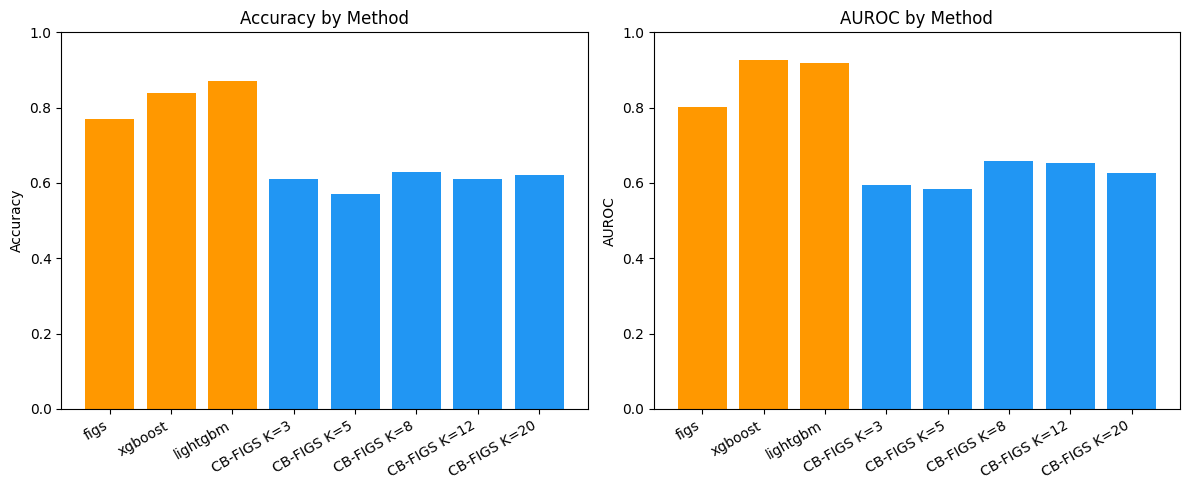

Results saved to results_comparison.png


In [12]:
from tabulate import tabulate

# ── Results Table ──
table_rows = []
for row in summary:
    method = row["method"]
    K = row.get("K")
    label = f"{method}" if K is None else f"{method} (K={K})"
    acc = row.get("accuracy_mean")
    acc_s = row.get("accuracy_std")
    auc = row.get("auroc_mean")
    auc_s = row.get("auroc_std")
    er = row.get("erank_mean")
    t = row.get("train_time_sec_mean")

    acc_str = f"{acc:.3f}+/-{acc_s:.3f}" if acc is not None else "N/A"
    auc_str = f"{auc:.3f}+/-{auc_s:.3f}" if auc is not None else "N/A"
    er_str = f"{er:.2f}" if er is not None else "-"
    t_str = f"{t:.3f}s" if t is not None else "N/A"

    table_rows.append([label, acc_str, auc_str, er_str, t_str])

headers = ["Method", "Accuracy", "AUROC", "eRank", "Time"]
print(tabulate(table_rows, headers=headers, tablefmt="grid"))

# ── Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

methods = []
accuracies = []
aurocs = []
for row in summary:
    K = row.get("K")
    label = row["method"] if K is None else f"CB-FIGS K={K}"
    methods.append(label)
    accuracies.append(row.get("accuracy_mean", 0) or 0)
    aurocs.append(row.get("auroc_mean", 0) or 0)

x = np.arange(len(methods))
colors = ['#2196F3' if 'CB-FIGS' in m else '#FF9800' for m in methods]

axes[0].bar(x, accuracies, color=colors)
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=30, ha='right')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy by Method')
axes[0].set_ylim(0, 1)

axes[1].bar(x, aurocs, color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=30, ha='right')
axes[1].set_ylabel('AUROC')
axes[1].set_title('AUROC by Method')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("results_comparison.png", dpi=100, bbox_inches="tight")
plt.show()
print("Results saved to results_comparison.png")